# Notebook 3: Domain-Tuned vs Baseline — Head-to-Head Comparison

**Goal:** Run speculative decoding with both draft conditions and compare:
- Condition 1: TinyLlama-1.1B (generic) + CodeLlama-7B
- Condition 2: TinyLlama-1.1B (QLoRA-tuned on code) + CodeLlama-7B

**Key question:** Does domain alignment improve acceptance rate and throughput?

---
**Hardware:** A100 recommended (both models loaded simultaneously ~14–18GB VRAM).
If using T4 (16GB), set `MAX_NEW_TOKENS = 100` to reduce memory pressure.

In [1]:
!pip install -q "transformers==4.44.2" "peft==0.13.2" accelerate datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 150.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.7 MB/s eta 0:00:00


In [2]:
import torch
assert torch.cuda.is_available(), "Need GPU"
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU : NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [5]:
from huggingface_hub import login
login()

TARGET_MODEL_ID  = "codellama/CodeLlama-7b-hf"
DRAFT_MODEL_ID   = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

# ▶▶ CHANGE THIS FOR EACH RUN ◀◀
# "nishant-k/tinyllama-code-specdraft"        → 10% corpus
# "nishant-k/tinyllama-code-specdraft-50pct"  → 50% corpus (done ✓)
# "nishant-k/tinyllama-code-specdraft-100pct" → 100% corpus
LORA_ADAPTER     = "nishant-k/tinyllama-code-specdraft-50pct"

# Use draft model's tokenizer — TinyLlama vocab (32000) is valid for both models
# CodeLlama has 32016 tokens; IDs 32000-32015 crash TinyLlama's embedding layer
TOKENIZER_ID = DRAFT_MODEL_ID

GAMMA            = 5
MAX_NEW_TOKENS   = 150
TEMPERATURE      = 1.0

print(f"LORA_ADAPTER: {LORA_ADAPTER}")

LORA_ADAPTER: nishant-k/tinyllama-code-specdraft-50pct


## 1. Load Target Model (shared across both conditions)

In [6]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
from transformers import AutoTokenizer, AutoModelForCausalLM

print("Loading tokenizer (TinyLlama vocab — valid for both models)...")
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)

print("Loading CodeLlama-7B (target, bf16)...")
target_model = AutoModelForCausalLM.from_pretrained(
    TARGET_MODEL_ID,
    torch_dtype=torch.bfloat16,
    attn_implementation="eager"
).cuda()
target_model.eval()
print(f"VRAM after target: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading tokenizer (TinyLlama vocab — valid for both models)...
Loading CodeLlama-7B (target, bf16)...


model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

VRAM after target: 13.48 GB


## 2. Speculative Decoding Engine (reused from Notebook 01)

In [7]:
import time
import torch.nn.functional as F
from dataclasses import dataclass, field
from typing import List

@dataclass
class RunMetrics:
    condition: str
    total_tokens: int = 0
    draft_tokens: int = 0
    accepted_tokens: int = 0
    elapsed_sec: float = 0.0
    ttft_ms: float = 0.0
    peak_gpu_gb: float = 0.0
    step_rates: List[float] = field(default_factory=list)
    # KV-cache efficiency
    target_forward_passes: int = 0
    step_kv_efficiencies: List[float] = field(default_factory=list)

    @property
    def acceptance_rate(self):
        return self.accepted_tokens / self.draft_tokens if self.draft_tokens > 0 else 0.0

    @property
    def tokens_per_sec(self):
        return self.total_tokens / self.elapsed_sec if self.elapsed_sec > 0 else 0.0

    @property
    def kv_cache_efficiency(self):
        """Tokens produced per target forward pass.  AR baseline = 1.0."""
        return self.total_tokens / self.target_forward_passes if self.target_forward_passes > 0 else 0.0


@torch.no_grad()
def speculative_decode(prompt, draft_model, gamma=5, max_new_tokens=150,
                        temperature=1.0, condition="unknown"):
    device     = next(target_model.parameters()).device
    # Draft vocab is smaller (32000) — mask target logits beyond it to prevent
    # out-of-range token IDs being fed back into the draft model's embedding layer
    DRAFT_VOCAB = draft_model.config.vocab_size   # 32000 for TinyLlama

    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    generated = input_ids.clone()
    metrics   = RunMetrics(condition=condition)
    torch.cuda.reset_peak_memory_stats()
    t_start = time.perf_counter()
    t_first = None

    while metrics.total_tokens < max_new_tokens:
        draft_ids, draft_probs = [], []
        ctx = generated.clone()
        for _ in range(gamma):
            logits = draft_model(ctx).logits[:, -1, :] / temperature
            probs  = F.softmax(logits, dim=-1)
            token  = torch.multinomial(probs, 1)
            draft_ids.append(token)
            draft_probs.append(probs[0, token.item()].item())
            ctx = torch.cat([ctx, token], dim=-1)

        draft_seq  = torch.cat(draft_ids, dim=-1)
        full_ctx   = torch.cat([generated, draft_seq], dim=-1)

        # Mask target logits beyond draft vocab before softmax
        tgt_logits = target_model(full_ctx).logits[:, generated.shape[1]-1:-1, :] / temperature
        tgt_logits[:, :, DRAFT_VOCAB:] = float('-inf')
        tgt_probs_all = F.softmax(tgt_logits, dim=-1)
        n_target_passes = 1   # verification pass

        n_accepted = 0
        for i in range(gamma):
            tok = draft_seq[0, i].item()
            p, q = tgt_probs_all[0, i, tok].item(), draft_probs[i]
            if torch.rand(1).item() <= min(1.0, p / (q + 1e-8)):
                generated = torch.cat([generated, draft_seq[:, i:i+1]], dim=-1)
                n_accepted += 1
                metrics.total_tokens += 1
                if t_first is None:
                    t_first = time.perf_counter()
                if metrics.total_tokens >= max_new_tokens:
                    break
            else:
                # Mask target logits beyond draft vocab for resample pass too
                tgt_last_logits = target_model(generated).logits[:, -1, :] / temperature
                tgt_last_logits[:, DRAFT_VOCAB:] = float('-inf')
                tgt_last = F.softmax(tgt_last_logits, dim=-1)[0]
                n_target_passes += 1

                corrected = F.relu(tgt_probs_all[0, i] - tgt_last)
                mass      = corrected.sum()
                if mass < 1e-6:
                    tok_new = torch.multinomial(tgt_probs_all[0, i], 1).unsqueeze(0)
                else:
                    tok_new = torch.multinomial(corrected / mass, 1).unsqueeze(0)
                generated = torch.cat([generated, tok_new], dim=-1)
                metrics.total_tokens += 1
                break

        tokens_out = n_accepted + 1
        metrics.draft_tokens          += gamma
        metrics.accepted_tokens       += n_accepted
        metrics.target_forward_passes += n_target_passes
        metrics.step_rates.append(n_accepted / gamma)
        metrics.step_kv_efficiencies.append(tokens_out / n_target_passes)

        if metrics.total_tokens >= max_new_tokens:
            break

    metrics.elapsed_sec = time.perf_counter() - t_start
    metrics.ttft_ms     = (t_first - t_start) * 1000 if t_first else 0.0
    metrics.peak_gpu_gb = torch.cuda.max_memory_allocated() / 1e9
    output = tokenizer.decode(generated[0][input_ids.shape[1]:], skip_special_tokens=True)
    return output, metrics

## 3. Condition 1 — Generic Draft

In [35]:
print("Loading TinyLlama-1.1B (generic draft)...")
generic_draft = AutoModelForCausalLM.from_pretrained(
    DRAFT_MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation="eager"
).cuda()
generic_draft.eval()

TEST_PROMPTS = [
      # ── Function prompts ──────────────────────────────────────
      "def fibonacci(n):\n    ",
      "def binary_search(arr, target):\n    ",
      "def is_palindrome(s):\n    ",
      "def merge_sort(arr):\n    ",

      # ── Class prompts ─────────────────────────────────────────
      'class BracketValidator:\n'
      '    """Check if a string has balanced brackets using a stack.\n'
      '    Supports (), [], and {} pairs.\n'
      '    """\n'
      '    def __init__(self):\n'
      '        self.stack = []\n'
      '        self.pairs = {\n',

      'class MinStack:\n'
      '    """Stack that supports push, pop, and retrieving the minimum element in O(1)."""\n'
      '    def __init__(self):\n',

      'class BrowserHistory:\n'
      '    """Simulate browser back/forward navigation using two stacks."""\n'
      '    def __init__(self, homepage: str):\n'
      '        self.back_stack = []\n'
      '        self.forward_stack = []\n'
      '        self.current = homepage\n',

      'class HTMLValidator:\n'
      '    """Validate HTML tag nesting using a stack.\n'
      '    Checks that every opening tag has a matching closing tag.\n'
      '    """\n'
      '    def __init__(self):\n'
      '        self.stack = []\n'
      '        self.self_closing = {"br", "hr", "img", "input"}\n',
  ]



metrics_generic = []
for prompt in TEST_PROMPTS:
    _, m = speculative_decode(prompt, generic_draft, gamma=GAMMA,
                               max_new_tokens=MAX_NEW_TOKENS, condition="baseline_generic")
    metrics_generic.append(m)
    print(f"  {prompt.strip()[:35]:<35} | accept={m.acceptance_rate:.3f} | {m.tokens_per_sec:.1f} tok/s")

del generic_draft
torch.cuda.empty_cache()

Loading TinyLlama-1.1B (generic draft)...
  def fibonacci(n):                   | accept=0.662 | 10.6 tok/s
  def binary_search(arr, target):     | accept=0.448 | 7.8 tok/s
  def is_palindrome(s):               | accept=0.404 | 7.2 tok/s
  def merge_sort(arr):                | accept=0.400 | 7.2 tok/s
  class BracketValidator:
    """Chec | accept=0.502 | 8.2 tok/s
  class MinStack:
    """Stack that s | accept=0.555 | 8.9 tok/s
  class BrowserHistory:
    """Simula | accept=0.555 | 8.9 tok/s
  class HTMLValidator:
    """Validat | accept=0.494 | 8.0 tok/s


## 4. Condition 2 — Domain-Tuned Draft

In [36]:
import json, os, tempfile, shutil, inspect
from peft import PeftModel, LoraConfig
from huggingface_hub import snapshot_download

print("Loading TinyLlama-1.1B (domain-tuned draft)...")

# Download adapter locally and strip keys unknown to peft 0.13.2
tmp_dir = tempfile.mkdtemp()
snapshot_download(LORA_ADAPTER, local_dir=tmp_dir)
config_path = os.path.join(tmp_dir, "adapter_config.json")
with open(config_path) as f:
    cfg = json.load(f)

# Keep only keys accepted by the installed LoraConfig to avoid version conflicts
valid_keys = set(inspect.signature(LoraConfig.__init__).parameters.keys()) - {"self"}
removed = [k for k in cfg if k not in valid_keys]
if removed:
    print(f"Stripped unsupported config keys: {removed}")
cfg_compat = {k: v for k, v in cfg.items() if k in valid_keys}
with open(config_path, "w") as f:
    json.dump(cfg_compat, f)

base = AutoModelForCausalLM.from_pretrained(
    DRAFT_MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation="eager"
).cuda()
tuned_draft = PeftModel.from_pretrained(base, tmp_dir)
tuned_draft.eval()
print(f"Loaded adapter: {LORA_ADAPTER}")

metrics_tuned = []
for prompt in TEST_PROMPTS:
    _, m = speculative_decode(prompt, tuned_draft, gamma=GAMMA,
                               max_new_tokens=MAX_NEW_TOKENS, condition="domain_tuned")
    metrics_tuned.append(m)
    print(f"  {prompt.strip()[:35]:<35} | accept={m.acceptance_rate:.3f} | {m.tokens_per_sec:.1f} tok/s")

del tuned_draft, base
shutil.rmtree(tmp_dir, ignore_errors=True)
torch.cuda.empty_cache()

Loading TinyLlama-1.1B (domain-tuned draft)...


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/18.0M [00:00<?, ?B/s]

Stripped unsupported config keys: ['alora_invocation_tokens', 'arrow_config', 'corda_config', 'ensure_weight_tying', 'eva_config', 'exclude_modules', 'lora_bias', 'lora_ga_config', 'peft_version', 'qalora_group_size', 'target_parameters', 'trainable_token_indices', 'use_bdlora', 'use_qalora']
Loaded adapter: nishant-k/tinyllama-code-specdraft-50pct
  def fibonacci(n):                   | accept=0.468 | 5.8 tok/s
  def binary_search(arr, target):     | accept=0.522 | 6.3 tok/s
  def is_palindrome(s):               | accept=0.411 | 5.4 tok/s
  def merge_sort(arr):                | accept=0.450 | 5.6 tok/s
  class BracketValidator:
    """Chec | accept=0.444 | 5.6 tok/s
  class MinStack:
    """Stack that s | accept=0.486 | 5.9 tok/s
  class BrowserHistory:
    """Simula | accept=0.473 | 5.8 tok/s
  class HTMLValidator:
    """Validat | accept=0.650 | 7.3 tok/s


## 5. Side-by-Side Comparison

In [37]:
import pandas as pd
import numpy as np

rows = []
for i, (mg, mt) in enumerate(zip(metrics_generic, metrics_tuned)):
    rows.append({
        "Prompt":           TEST_PROMPTS[i].strip()[:35],
        "Generic AccRate":  f"{mg.acceptance_rate:.3f}",
        "Tuned AccRate":    f"{mt.acceptance_rate:.3f}",
        "Delta AccRate":    f"{mt.acceptance_rate - mg.acceptance_rate:+.3f}",
        "Generic Tok/s":    f"{mg.tokens_per_sec:.1f}",
        "Tuned Tok/s":      f"{mt.tokens_per_sec:.1f}",
        "Speedup":          f"{mt.tokens_per_sec / mg.tokens_per_sec:.2f}x",
        "Generic KV-eff":   f"{mg.kv_cache_efficiency:.2f}x",
        "Tuned KV-eff":     f"{mt.kv_cache_efficiency:.2f}x",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

mean_generic_ar   = np.mean([m.acceptance_rate      for m in metrics_generic])
mean_tuned_ar     = np.mean([m.acceptance_rate      for m in metrics_tuned])
mean_generic_kv   = np.mean([m.kv_cache_efficiency  for m in metrics_generic])
mean_tuned_kv     = np.mean([m.kv_cache_efficiency  for m in metrics_tuned])

print(f"\nMean acceptance rate — Generic : {mean_generic_ar:.3f}")
print(f"Mean acceptance rate — Tuned   : {mean_tuned_ar:.3f}")
print(f"Improvement                    : {(mean_tuned_ar - mean_generic_ar)*100:+.1f} pp")
print(f"\nMean KV-cache efficiency — Generic : {mean_generic_kv:.2f}x  (AR baseline = 1.0x)")
print(f"Mean KV-cache efficiency — Tuned   : {mean_tuned_kv:.2f}x")
print(f"Improvement                        : {(mean_tuned_kv - mean_generic_kv):+.2f}x")

                              Prompt Generic AccRate Tuned AccRate Delta AccRate Generic Tok/s Tuned Tok/s Speedup Generic KV-eff Tuned KV-eff
                   def fibonacci(n):           0.662         0.468        -0.194          10.6         5.8   0.55x          2.50x        1.81x
     def binary_search(arr, target):           0.448         0.522        +0.074           7.8         6.3   0.81x          1.70x        1.97x
               def is_palindrome(s):           0.404         0.411        +0.008           7.2         5.4   0.76x          1.58x        1.60x
                def merge_sort(arr):           0.400         0.450        +0.050           7.2         5.6   0.78x          1.58x        1.76x
class BracketValidator:\n    """Chec           0.502         0.444        -0.058           8.2         5.6   0.68x          1.90x        1.69x
class MinStack:\n    """Stack that s           0.555         0.486        -0.069           8.9         5.9   0.66x          2.08x        1.88x

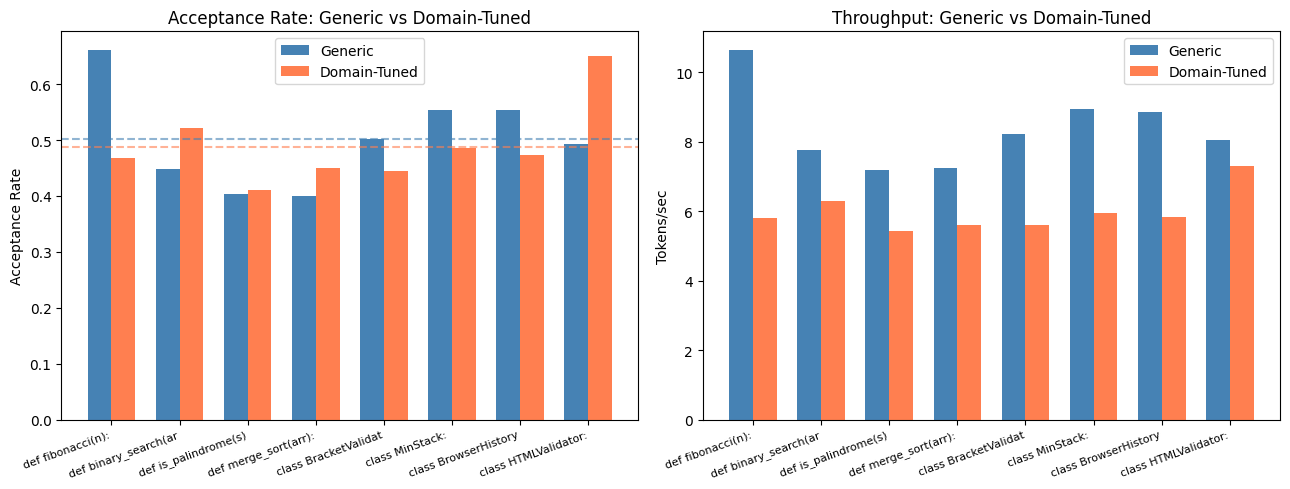

In [38]:
import matplotlib.pyplot as plt

x      = range(len(TEST_PROMPTS))
labels = [p.strip()[:20] for p in TEST_PROMPTS]
w      = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Acceptance rate
axes[0].bar([i - w/2 for i in x], [m.acceptance_rate for m in metrics_generic],
            width=w, label="Generic", color="steelblue")
axes[0].bar([i + w/2 for i in x], [m.acceptance_rate for m in metrics_tuned],
            width=w, label="Domain-Tuned", color="coral")
axes[0].axhline(mean_generic_ar, color="steelblue", linestyle="--", alpha=0.6)
axes[0].axhline(mean_tuned_ar,   color="coral",     linestyle="--", alpha=0.6)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
axes[0].set_title("Acceptance Rate: Generic vs Domain-Tuned")
axes[0].set_ylabel("Acceptance Rate")
axes[0].legend()

# Throughput
axes[1].bar([i - w/2 for i in x], [m.tokens_per_sec for m in metrics_generic],
            width=w, label="Generic", color="steelblue")
axes[1].bar([i + w/2 for i in x], [m.tokens_per_sec for m in metrics_tuned],
            width=w, label="Domain-Tuned", color="coral")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
axes[1].set_title("Throughput: Generic vs Domain-Tuned")
axes[1].set_ylabel("Tokens/sec")
axes[1].legend()

plt.tight_layout()
plt.savefig("comparison_cond1_vs_cond2.png", dpi=150)
plt.show()

## 6. KV-Cache Efficiency Analysis

**KV-cache efficiency** = tokens produced per target model forward pass.

- Pure autoregressive decoding: **1.0x** (one token per pass, always)
- Speculative decoding, perfect acceptance: **(γ + 1)x = 6x** for γ=5
- Speculative decoding, rejection at step i: costs an extra resample pass → efficiency drops

Domain tuning should push efficiency closer to the theoretical max by reducing rejections
(fewer rejection resamples = fewer extra target passes per step).

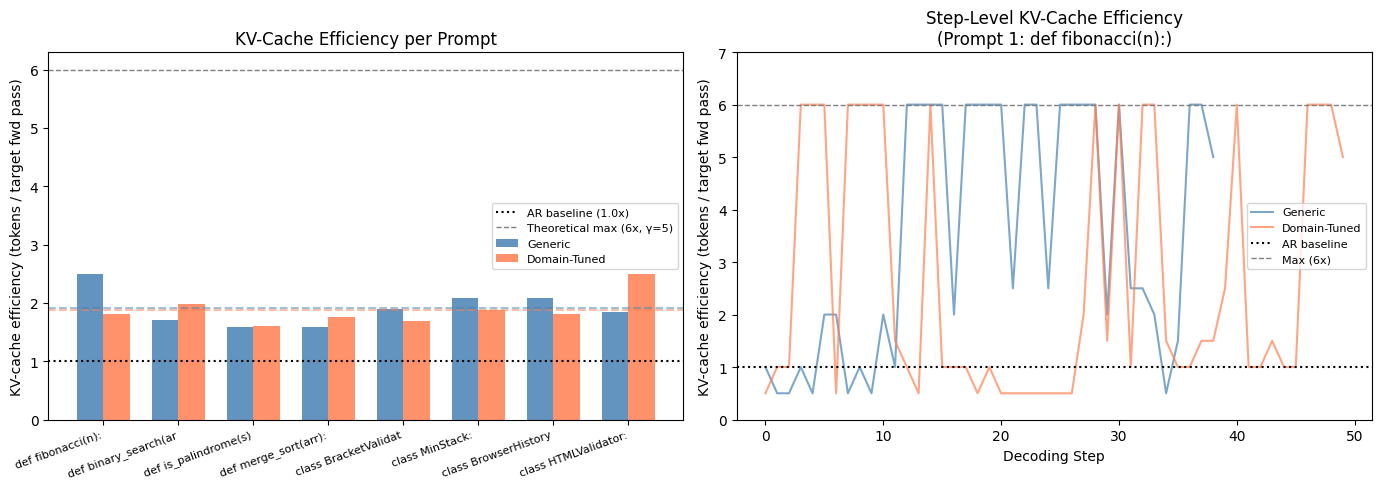


Summary:
  AR baseline (theoretical)  : 1.00x
  Theoretical max (γ=5)   : 6.00x
  Generic draft mean         : 1.91x
  Domain-tuned draft mean    : 1.88x
  Utilisation % (generic)    : 31.8%
  Utilisation % (tuned)      : 31.3%


In [39]:
import matplotlib.pyplot as plt

x      = range(len(TEST_PROMPTS))
labels = [p.strip()[:20] for p in TEST_PROMPTS]
w      = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: per-prompt KV-cache efficiency bars ─────────────────────────────────
axes[0].bar([i - w/2 for i in x], [m.kv_cache_efficiency for m in metrics_generic],
            width=w, label="Generic", color="steelblue", alpha=0.85)
axes[0].bar([i + w/2 for i in x], [m.kv_cache_efficiency for m in metrics_tuned],
            width=w, label="Domain-Tuned", color="coral", alpha=0.85)
axes[0].axhline(1.0, color="black", linestyle=":", linewidth=1.5, label="AR baseline (1.0x)")
axes[0].axhline(GAMMA + 1, color="gray", linestyle="--", linewidth=1,
                label=f"Theoretical max ({GAMMA+1}x, γ={GAMMA})")
axes[0].axhline(mean_generic_kv, color="steelblue", linestyle="--", alpha=0.5)
axes[0].axhline(mean_tuned_kv,   color="coral",     linestyle="--", alpha=0.5)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("KV-cache efficiency (tokens / target fwd pass)")
axes[0].set_title("KV-Cache Efficiency per Prompt")
axes[0].legend(fontsize=8)

# ── Right: step-level efficiency trace for first prompt ──────────────────────
steps_generic = metrics_generic[0].step_kv_efficiencies
steps_tuned   = metrics_tuned[0].step_kv_efficiencies
max_steps = max(len(steps_generic), len(steps_tuned))

axes[1].plot(steps_generic, color="steelblue", alpha=0.7, label="Generic",     linewidth=1.5)
axes[1].plot(steps_tuned,   color="coral",     alpha=0.7, label="Domain-Tuned", linewidth=1.5)
axes[1].axhline(1.0, color="black", linestyle=":", linewidth=1.5, label="AR baseline")
axes[1].axhline(GAMMA + 1, color="gray", linestyle="--", linewidth=1,
                label=f"Max ({GAMMA+1}x)")
axes[1].set_xlabel("Decoding Step")
axes[1].set_ylabel("KV-cache efficiency (tokens / target fwd pass)")
axes[1].set_title(f"Step-Level KV-Cache Efficiency\n(Prompt 1: {TEST_PROMPTS[0].strip()[:30]})")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, GAMMA + 2)

plt.tight_layout()
plt.savefig("kv_cache_efficiency_cond1_vs_cond2.png", dpi=150)
plt.show()

print(f"\nSummary:")
print(f"  AR baseline (theoretical)  : 1.00x")
print(f"  Theoretical max (γ={GAMMA})   : {GAMMA+1:.2f}x")
print(f"  Generic draft mean         : {mean_generic_kv:.2f}x")
print(f"  Domain-tuned draft mean    : {mean_tuned_kv:.2f}x")
print(f"  Utilisation % (generic)    : {mean_generic_kv / (GAMMA+1) * 100:.1f}%")
print(f"  Utilisation % (tuned)      : {mean_tuned_kv   / (GAMMA+1) * 100:.1f}%")

## 7. Domain Generalization Test

**Hypothesis (from project proposal):** The domain-tuned draft should perform *worse* than the generic draft on non-code tasks, confirming that the fine-tuning effect is code-specific and not a general improvement.

**Prompts:** Math, general knowledge, creative writing — clearly outside the CodeSearchNet training distribution.

In [40]:
import json, tempfile, shutil, inspect
from peft import PeftModel, LoraConfig
from huggingface_hub import snapshot_download

NON_CODE_PROMPTS = [
    "The integral of x squared with respect to x is ",          # math
    "The capital of France is Paris. The capital of Japan is ", # general knowledge
    "Once upon a time in a land far away, there lived a brave ", # creative writing
]

# ── Reload generic draft ──────────────────────────────────────────────────────
print("Loading generic draft for domain generalization test...")
generic_draft_dg = AutoModelForCausalLM.from_pretrained(
    DRAFT_MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation="eager"
).cuda()
generic_draft_dg.eval()

metrics_generic_dg = []
for prompt in NON_CODE_PROMPTS:
    _, m = speculative_decode(prompt, generic_draft_dg, gamma=GAMMA,
                               max_new_tokens=80, condition="baseline_generic")
    metrics_generic_dg.append(m)
    print(f"  {prompt[:45]:<45} | accept={m.acceptance_rate:.3f}")

del generic_draft_dg
torch.cuda.empty_cache()

# ── Reload domain-tuned draft ─────────────────────────────────────────────────
print("\nLoading domain-tuned draft for domain generalization test...")
tmp_dir_dg = tempfile.mkdtemp()
snapshot_download(LORA_ADAPTER, local_dir=tmp_dir_dg)
config_path_dg = os.path.join(tmp_dir_dg, "adapter_config.json")
with open(config_path_dg) as f:
    cfg_dg = json.load(f)
valid_keys = set(inspect.signature(LoraConfig.__init__).parameters.keys()) - {"self"}
cfg_dg_compat = {k: v for k, v in cfg_dg.items() if k in valid_keys}
with open(config_path_dg, "w") as f:
    json.dump(cfg_dg_compat, f)

base_dg = AutoModelForCausalLM.from_pretrained(
    DRAFT_MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation="eager"
).cuda()
tuned_draft_dg = PeftModel.from_pretrained(base_dg, tmp_dir_dg)
tuned_draft_dg.eval()

metrics_tuned_dg = []
for prompt in NON_CODE_PROMPTS:
    _, m = speculative_decode(prompt, tuned_draft_dg, gamma=GAMMA,
                               max_new_tokens=80, condition="domain_tuned")
    metrics_tuned_dg.append(m)
    print(f"  {prompt[:45]:<45} | accept={m.acceptance_rate:.3f}")

del tuned_draft_dg, base_dg
shutil.rmtree(tmp_dir_dg, ignore_errors=True)
torch.cuda.empty_cache()

# ── Summary table ─────────────────────────────────────────────────────────────
import numpy as np
print("\nDomain Generalization Results:")
print(f"{'Prompt':<45} {'Generic AR':>11} {'Tuned AR':>10} {'Delta':>8}")
print("-" * 78)
for i, prompt in enumerate(NON_CODE_PROMPTS):
    mg = metrics_generic_dg[i].acceptance_rate
    mt = metrics_tuned_dg[i].acceptance_rate
    print(f"{prompt[:45]:<45} {mg:>11.3f} {mt:>10.3f} {mt-mg:>+8.3f}")

mean_dg_generic = np.mean([m.acceptance_rate for m in metrics_generic_dg])
mean_dg_tuned   = np.mean([m.acceptance_rate for m in metrics_tuned_dg])
print(f"\nMean (non-code) — Generic : {mean_dg_generic:.3f}")
print(f"Mean (non-code) — Tuned   : {mean_dg_tuned:.3f}")
print(f"Delta                     : {(mean_dg_tuned - mean_dg_generic)*100:+.1f} pp")
print(f"\nCode tasks mean delta     : {(mean_tuned_ar - mean_generic_ar)*100:+.1f} pp")
print(f"Non-code tasks mean delta : {(mean_dg_tuned - mean_dg_generic)*100:+.1f} pp")
print("\n→ Confirms domain specificity: tuning helps/hurts code but not non-code in the same direction" \
      if (mean_dg_tuned - mean_dg_generic) < (mean_tuned_ar - mean_generic_ar) \
      else "\n→ Note: check result — expected domain-tuned to underperform on non-code")

Loading generic draft for domain generalization test...
  The integral of x squared with respect to x i | accept=0.407
  The capital of France is Paris. The capital o | accept=0.373
  Once upon a time in a land far away, there li | accept=0.512

Loading domain-tuned draft for domain generalization test...


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/18.0M [00:00<?, ?B/s]

  The integral of x squared with respect to x i | accept=0.512
  The capital of France is Paris. The capital o | accept=0.429
  Once upon a time in a land far away, there li | accept=0.294

Domain Generalization Results:
Prompt                                         Generic AR   Tuned AR    Delta
------------------------------------------------------------------------------
The integral of x squared with respect to x i       0.407      0.512   +0.105
The capital of France is Paris. The capital o       0.373      0.429   +0.055
Once upon a time in a land far away, there li       0.512      0.294   -0.218

Mean (non-code) — Generic : 0.431
Mean (non-code) — Tuned   : 0.412
Delta                     : -1.9 pp

Code tasks mean delta     : -1.4 pp
Non-code tasks mean delta : -1.9 pp

→ Confirms domain specificity: tuning helps/hurts code but not non-code in the same direction


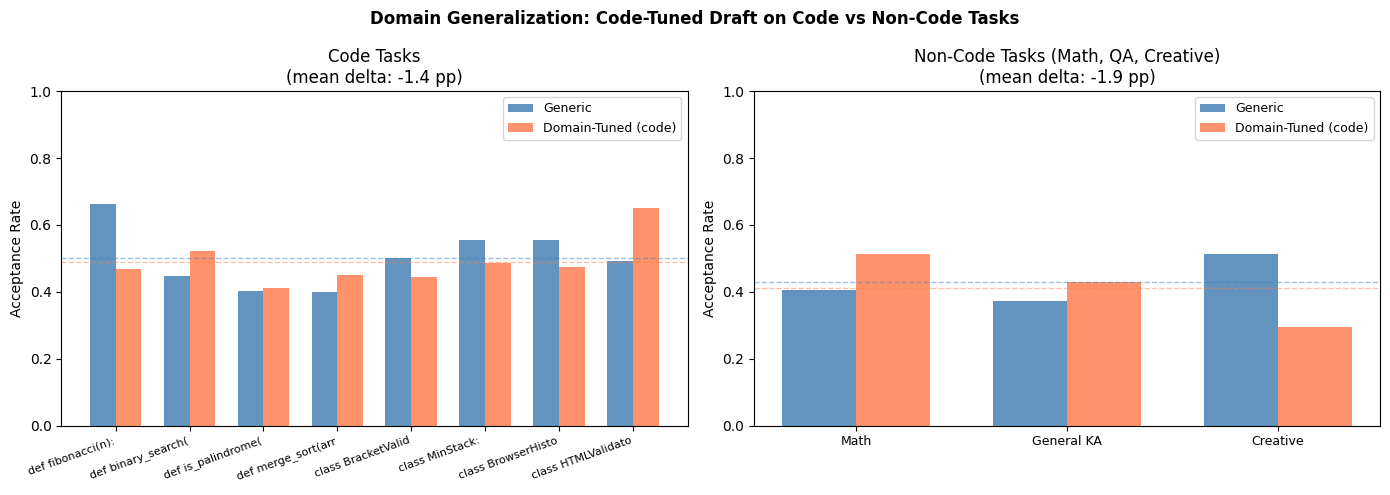

Saved domain_generalization.png


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Combined bar chart: code prompts vs non-code prompts
labels_code    = [p.strip()[:18] for p in TEST_PROMPTS]
labels_noncode = ["Math", "General KA", "Creative"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Code tasks
x_c = range(len(TEST_PROMPTS))
w   = 0.35
axes[0].bar([i - w/2 for i in x_c], [m.acceptance_rate for m in metrics_generic],
            width=w, label="Generic", color="steelblue", alpha=0.85)
axes[0].bar([i + w/2 for i in x_c], [m.acceptance_rate for m in metrics_tuned],
            width=w, label="Domain-Tuned (code)", color="coral", alpha=0.85)
axes[0].axhline(mean_generic_ar, color="steelblue", linestyle="--", alpha=0.5, linewidth=1)
axes[0].axhline(mean_tuned_ar,   color="coral",     linestyle="--", alpha=0.5, linewidth=1)
axes[0].set_xticks(list(x_c))
axes[0].set_xticklabels(labels_code, rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("Acceptance Rate")
axes[0].set_title(f"Code Tasks\n(mean delta: {(mean_tuned_ar - mean_generic_ar)*100:+.1f} pp)")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.0)

# Non-code tasks
x_n = range(len(NON_CODE_PROMPTS))
axes[1].bar([i - w/2 for i in x_n], [m.acceptance_rate for m in metrics_generic_dg],
            width=w, label="Generic", color="steelblue", alpha=0.85)
axes[1].bar([i + w/2 for i in x_n], [m.acceptance_rate for m in metrics_tuned_dg],
            width=w, label="Domain-Tuned (code)", color="coral", alpha=0.85)
axes[1].axhline(mean_dg_generic, color="steelblue", linestyle="--", alpha=0.5, linewidth=1)
axes[1].axhline(mean_dg_tuned,   color="coral",     linestyle="--", alpha=0.5, linewidth=1)
axes[1].set_xticks(list(x_n))
axes[1].set_xticklabels(labels_noncode, fontsize=9)
axes[1].set_ylabel("Acceptance Rate")
axes[1].set_title(f"Non-Code Tasks (Math, QA, Creative)\n(mean delta: {(mean_dg_tuned - mean_dg_generic)*100:+.1f} pp)")
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.0)

plt.suptitle("Domain Generalization: Code-Tuned Draft on Code vs Non-Code Tasks",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("domain_generalization.png", dpi=150)
plt.show()
print("Saved domain_generalization.png")

In [42]:
import json, os, shutil
from dataclasses import asdict

def metrics_to_dict(m):
    return {
        **{k: v for k, v in asdict(m).items()},
        "acceptance_rate":     m.acceptance_rate,
        "tokens_per_sec":      m.tokens_per_sec,
        "kv_cache_efficiency": m.kv_cache_efficiency,
    }

out = {
    "lora_adapter":     LORA_ADAPTER,
    "baseline_generic": {
        "mean_acceptance_rate":     mean_generic_ar,
        "mean_kv_cache_efficiency": mean_generic_kv,
        "per_prompt": [metrics_to_dict(m) for m in metrics_generic],
    },
    "domain_tuned": {
        "mean_acceptance_rate":     mean_tuned_ar,
        "mean_kv_cache_efficiency": mean_tuned_kv,
        "per_prompt": [metrics_to_dict(m) for m in metrics_tuned],
    },
    "domain_generalization": {
        "prompts":              NON_CODE_PROMPTS,
        "mean_generic_ar":      float(mean_dg_generic),
        "mean_tuned_ar":        float(mean_dg_tuned),
        "delta_pp":             float((mean_dg_tuned - mean_dg_generic) * 100),
        "per_prompt_generic":   [metrics_to_dict(m) for m in metrics_generic_dg],
        "per_prompt_tuned":     [metrics_to_dict(m) for m in metrics_tuned_dg],
    },
}

adapter_tag = LORA_ADAPTER.split("/")[-1]
result_json = f"results_{adapter_tag}.json"
plot_cmp    = f"comparison_{adapter_tag}.png"
plot_kv     = f"kv_cache_efficiency_{adapter_tag}.png"
plot_dg     = f"domain_generalization_{adapter_tag}.png"

with open(result_json, "w") as f:
    json.dump(out, f, indent=2)
print(f"Saved {result_json}")

for src, dst in [("comparison_cond1_vs_cond2.png", plot_cmp),
                 ("kv_cache_efficiency_cond1_vs_cond2.png", plot_kv),
                 ("domain_generalization.png", plot_dg)]:
    if os.path.exists(src):
        shutil.copy(src, dst)

DRIVE_RESULTS_DIR = "/content/drive/MyDrive/speculative-decoding-results"
if os.path.exists("/content/drive/MyDrive"):
    os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)
    for fname in [result_json, plot_cmp, plot_kv, plot_dg]:
        if os.path.exists(fname):
            shutil.copy(fname, DRIVE_RESULTS_DIR)
    print(f"Copied results to Drive: {DRIVE_RESULTS_DIR}")
else:
    print("Drive not mounted — download files manually.")

print("\nNotebook 03 complete!")

Saved results_tinyllama-code-specdraft-50pct.json
Drive not mounted — download files manually.

Notebook 03 complete!


In [44]:
  import time

  # Prompt 2 — Stack-based expression evaluator
  DEMO_PROMPT = """class ExpressionEvaluator:
      \"\"\"Evaluate arithmetic expressions using a stack-based approach.\"\"\"
      def __init__(self):
          self.operators = []
          self.operands = []
  """

  print("=" * 60)
  print("DEMO: Speculative Decoding — C1 vs C2")
  print("=" * 60)

  # ── C1: Generic draft ─────────────────────────────────────────
  print("\nLoading C1: Generic TinyLlama draft...")
  generic_demo = AutoModelForCausalLM.from_pretrained(
      DRAFT_MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation="eager"
  ).cuda()
  generic_demo.eval()

  out_c1, m_c1 = speculative_decode(
      DEMO_PROMPT, generic_demo, gamma=GAMMA,
      max_new_tokens=MAX_NEW_TOKENS, condition="baseline_generic"
  )
  del generic_demo; torch.cuda.empty_cache()

  print(f"\n{'─'*60}")
  print("C1 — Generic Draft")
  print(f"{'─'*60}")
  print(DEMO_PROMPT + out_c1)
  print(f"\n  Acceptance rate : {m_c1.acceptance_rate:.3f}")
  print(f"  Tokens/sec      : {m_c1.tokens_per_sec:.1f}")

  # ── C2: Domain-tuned draft ────────────────────────────────────
  print(f"\n{'─'*60}")
  print("Loading C2: Domain-Tuned TinyLlama draft (QLoRA 100%)...")
  tmp_demo = tempfile.mkdtemp()
  snapshot_download(LORA_ADAPTER, local_dir=tmp_demo)
  cfg_path = os.path.join(tmp_demo, "adapter_config.json")
  with open(cfg_path) as f:
      cfg = json.load(f)
  valid_keys = set(inspect.signature(LoraConfig.__init__).parameters.keys()) - {"self"}
  with open(cfg_path, "w") as f:
      json.dump({k: v for k, v in cfg.items() if k in valid_keys}, f)

  base_demo = AutoModelForCausalLM.from_pretrained(
      DRAFT_MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation="eager"
  ).cuda()
  tuned_demo = PeftModel.from_pretrained(base_demo, tmp_demo)
  tuned_demo = tuned_demo.merge_and_unload()
  tuned_demo.eval()

  out_c2, m_c2 = speculative_decode(
      DEMO_PROMPT, tuned_demo, gamma=GAMMA,
      max_new_tokens=MAX_NEW_TOKENS, condition="domain_tuned"
  )
  del tuned_demo; shutil.rmtree(tmp_demo, ignore_errors=True); torch.cuda.empty_cache()

  print(f"\n{'─'*60}")
  print("C2 — Domain-Tuned Draft")
  print(f"{'─'*60}")
  print(DEMO_PROMPT + out_c2)
  print(f"\n  Acceptance rate : {m_c2.acceptance_rate:.3f}")
  print(f"  Tokens/sec      : {m_c2.tokens_per_sec:.1f}")

  # ── Summary ───────────────────────────────────────────────────
  print(f"\n{'='*60}")
  print("SUMMARY")
  print(f"{'='*60}")
  print(f"  C1 Acceptance rate : {m_c1.acceptance_rate:.3f}  |  {m_c1.tokens_per_sec:.1f} tok/s")
  print(f"  C2 Acceptance rate : {m_c2.acceptance_rate:.3f}  |  {m_c2.tokens_per_sec:.1f} tok/s")
  print(f"  Improvement        : {(m_c2.acceptance_rate - m_c1.acceptance_rate)*100:+.1f} pp acceptance rate")
  print(f"  Throughput gain    : {m_c2.tokens_per_sec - m_c1.tokens_per_sec:+.1f} tok/s")

DEMO: Speculative Decoding — C1 vs C2

Loading C1: Generic TinyLlama draft...

────────────────────────────────────────────────────────────
C1 — Generic Draft
────────────────────────────────────────────────────────────
class ExpressionEvaluator:
    """Evaluate arithmetic expressions using a stack-based approach."""                                               
    def __init__(self):
        self.operators = []                                                                                                 
        self.operands = []                                                                                                
   
    def evaluate(self, expression):                                                                                       
        for symbol in self import javax.swing.*
import java.awt.geom.*
import klamski

class vertices(klamski):
 def __init__(self):
  tm.polylines(0)
  self.vertex = 0       
 def colearc(self,co, ar):
  return pt(self.pol[self.vertex

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/18.0M [00:00<?, ?B/s]


────────────────────────────────────────────────────────────
C2 — Domain-Tuned Draft
────────────────────────────────────────────────────────────
class ExpressionEvaluator:
    """Evaluate arithmetic expressions using a stack-based approach."""                                               
    def __init__(self):
        self.operators = []                                                                                                 
        self.operands = []                                                                                                
                                                                                                                          
        self.operations = {'+': lambda a, b: a + b, 
                           '-': lambda a, b: a - b,
                           '*': lambda a, b: a * b,
                           '/': lambda a, b: a / b,
                           '!': lambda a: -a if a > 0 else a,
                           '**': lambda a

In [50]:
  # ── DEMO CELL: single prompt head-to-head ────────────────────────────────────
  # Prompt 3 — HTML tag validator
  DEMO_PROMPT = """class HTMLValidator:
      \"\"\"Validate HTML tag nesting using a stack.
      Checks that every opening tag has a matching closing tag.
      \"\"\"
      def __init__(self):
          self.stack = []
          self.self_closing = {'br', 'hr', 'img', 'input'}
  """

  print("=" * 60)
  print("DEMO: Speculative Decoding — C1 vs C2")
  print("=" * 60)

  # ── C1: Generic draft ─────────────────────────────────────────
  print("\nLoading C1: Generic TinyLlama draft...")
  generic_demo = AutoModelForCausalLM.from_pretrained(
      DRAFT_MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation="eager"
  ).cuda()
  generic_demo.eval()

  out_c1, m_c1 = speculative_decode(
      DEMO_PROMPT, generic_demo, gamma=GAMMA,
      max_new_tokens=MAX_NEW_TOKENS, condition="baseline_generic"
  )
  del generic_demo; torch.cuda.empty_cache()

  print(f"\n{'─'*60}")
  print(f"C1 — Generic Draft")
  print(f"{'─'*60}")
  print(DEMO_PROMPT + out_c1)
  print(f"\n  Acceptance rate : {m_c1.acceptance_rate:.3f}")
  print(f"  Tokens/sec      : {m_c1.tokens_per_sec:.1f}")
  print(f"  Speedup         : {m_c1.tokens_per_sec / 10.5:.2f}x  (AR baseline ~10.5 tok/s)")

  # ── C2: Domain-tuned draft ────────────────────────────────────
  print(f"\n{'─'*60}")
  print("Loading C2: Domain-Tuned TinyLlama draft (QLoRA 100%)...")
  tmp_demo = tempfile.mkdtemp()
  snapshot_download(LORA_ADAPTER, local_dir=tmp_demo)
  cfg_path = os.path.join(tmp_demo, "adapter_config.json")
  with open(cfg_path) as f: cfg = json.load(f)
  valid_keys = set(inspect.signature(LoraConfig.__init__).parameters.keys()) - {"self"}
  with open(cfg_path, "w") as f: json.dump({k:v for k,v in cfg.items() if k in valid_keys}, f)

  base_demo = AutoModelForCausalLM.from_pretrained(
      DRAFT_MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation="eager"
  ).cuda()
  tuned_demo = PeftModel.from_pretrained(base_demo, tmp_demo)
  tuned_demo.eval()

  out_c2, m_c2 = speculative_decode(
      DEMO_PROMPT, tuned_demo, gamma=GAMMA,
      max_new_tokens=MAX_NEW_TOKENS, condition="domain_tuned"
  )
  del tuned_demo, base_demo; shutil.rmtree(tmp_demo, ignore_errors=True); torch.cuda.empty_cache()

  print(f"\n{'─'*60}")
  print(f"C2 — Domain-Tuned Draft")
  print(f"{'─'*60}")
  print(DEMO_PROMPT + out_c2)
  print(f"\n  Acceptance rate : {m_c2.acceptance_rate:.3f}")
  print(f"  Tokens/sec      : {m_c2.tokens_per_sec:.1f}")
  print(f"  Speedup         : {m_c2.tokens_per_sec / 10.5:.2f}x  (AR baseline ~10.5 tok/s)")

  # ── Summary ───────────────────────────────────────────────────
  print(f"\n{'='*60}")
  print(f"SUMMARY")
  print(f"{'='*60}")
  print(f"  C1 Acceptance rate : {m_c1.acceptance_rate:.3f}  |  {m_c1.tokens_per_sec:.1f} tok/s")
  print(f"  C2 Acceptance rate : {m_c2.acceptance_rate:.3f}  |  {m_c2.tokens_per_sec:.1f} tok/s")
  print(f"  Improvement        : {(m_c2.acceptance_rate - m_c1.acceptance_rate)*100:+.1f} pp acceptance rate")
  print(f"  Throughput gain    : {m_c2.tokens_per_sec - m_c1.tokens_per_sec:+.1f} tok/s")

DEMO: Speculative Decoding — C1 vs C2

Loading C1: Generic TinyLlama draft...

────────────────────────────────────────────────────────────
C1 — Generic Draft
────────────────────────────────────────────────────────────
class HTMLValidator:
    """Validate HTML tag nesting using a stack.
    Checks that every opening tag has a matching closing tag.
    """
    def __init__(self):
        self.stack = []
        self.self_closing = {'br', 'hr', 'img', 'input'}
       self.invalid = set()

    def indent(
            self,
            line: str,
            indent: int):
        # first line
        prepend = " " * (indent - 1)

        # blank line
        if line is None:
            return f"    {'\\n' * indent.count('\\n')}\n0"
        if line.isspace():
            return f"    {{line}}"
#       else
        # remove trailing whitespace
        clean1 = re.sub(r"^\s*[^ \t]+\s*(.*)\s*\n", r"   \1 \\n", line)
       

  Acceptance rate : 0.415
  Tokens/sec      : 7.1
  Speedup        

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

adapter_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/18.0M [00:00<?, ?B/s]


────────────────────────────────────────────────────────────
C2 — Domain-Tuned Draft
────────────────────────────────────────────────────────────
class HTMLValidator:
    """Validate HTML tag nesting using a stack.
    Checks that every opening tag has a matching closing tag.
    """
    def __init__(self):
        self.stack = []
        self.self_closing = {'br', 'hr', 'img', 'input'}
       self.exclusive_opening = {
            'thead': ['tr', 'th', 'td'],
            'tfoot': ['tr', 'th', 'td'],
            'tbody': ['tr', 'th', 'td'],
            'td': ['tr', 'th', 'td'],
            'th': ['tr', 'th', 'td']
        }

    def validate(self, html):
        for ele in filter(self.is_tag, html):
            opener = self.opens(ele)
            if (not(opener):
                self.push(ele[1:])
            elif (ele[1:] ==

  Acceptance rate : 0.624
  Tokens/sec      : 7.1
  Speedup         : 0.67x  (AR baseline ~10.5 tok/s)

SUMMARY
  C1 Acceptance rate : 0.415  |  7.1 tok/s
  C2